# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Kadek Intan Dheya Pratiwi]
- **Email:** [intandheya11@gmail.com]
- **ID Dicoding:** [CDCC014D6X1038]

## Menentukan Pertanyaan Bisnis



1. Bagaimana perbedaan rata-rata jumlah penyewaan sepeda berdasarkan kategori waktu (pagi, siang, sore, malam) selama tahun 2011–2012?

2. Seberapa besar rata-rata jumlah penyewaan sepeda berdasarkan kondisi cuaca selama tahun 2011–2012, dan kondisi cuaca mana yang menghasilkan permintaan tertinggi?

3. Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara hari kerja dan hari libur selama tahun 2011–2012?

4. Bagaimana distribusi tingkat penggunaan sepeda (rendah, sedang, tinggi) selama tahun 2011–2012 dan apa artinya untuk pola permintaan?





## Import Semua Packages/Library yang Digunakan

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [64]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:


*  Dataset berhasil dimuat yang terdiri dari data harian dan data per jam. Dari tampilan awal, terlihat bahwa jumlah penyewaan sepeda (cnt) dipengaruhi oleh berbagai faktor seperti waktu, kondisi cuaca, dan jenis pengguna. Selain itu, jumlah pengguna registered terlihat lebih dominan dibandingkan casual, yang mengindikasikan bahwa layanan bike sharing lebih banyak digunakan oleh pelanggan tetap.




### Assessing Data

Struktur Data & Tipe Data

In [65]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

MIssing Value & Duplikasi

In [66]:
print("Missing value day:\n", day_df.isna().sum())
print("Missing value day:\n", hour_df.isna().sum())

print("Duplikasi day:", day_df.duplicated().sum())
print("Duplikasi day:", hour_df.duplicated().sum())

Missing value day:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Missing value day:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Duplikasi day: 0
Duplikasi day: 0


Statistik Deskriptif

In [67]:
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Nilai Unik

In [68]:
day_df.nunique()
hour_df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


**Insight** :
Berdasarkan proses assesing data. dapat disimpulkan bahwa kualitas dataset tergolong baik karena tidak ditemukan missing value maupun data duplikat pada kedua dataset.
Namun, terdapat beberapa hal yang perlu diperhatikan sebelum analisis lebih lanjut :


1.   Kolom 'dteday' masih bertope object dan perlu dikonversi menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.
2.   Beberapa variabel seperti 'season'. 'weatherlist','workingday', dan 'holiday' memiliki jumlah nilai unik yang terbatas, sehingga lebih tepat diperlakukan sebagai data kategorikal.
3.  Hasil statistik deskriptif menunjukkan adanya variasi yang cukup besar pada jumlah penyewaan sepeda (cnt), yang mengindikasikan fluktuasi permintaan yang signifikan sepanjang waktu.
4.  Perbedaan antara jumlah pengguna casual dan registered cukup tinggi, yang menunjukkan adanya perbedaan perilaku penggunaan layanan.




### Cleaning Data

In [69]:

# CLEANING DATA


# Copy dataset
df_day = day_df.copy()
df_hour = hour_df.copy()

# Convert date
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

# Season mapping
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

df_day['season'] = df_day['season'].map(season_map)
df_hour['season'] = df_hour['season'].map(season_map)

# Weather mapping
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

df_day['weathersit'] = df_day['weathersit'].map(weather_map)
df_hour['weathersit'] = df_hour['weathersit'].map(weather_map)

# Working day mapping
df_day['workingday'] = df_day['workingday'].map({0: 'No', 1: 'Yes'})
df_hour['workingday'] = df_hour['workingday'].map({0: 'No', 1: 'Yes'})

# Time category (hourly only)
def categorize_time(hour):
    if 5 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 19:
        return 'Evening'
    else:
        return 'Night'

df_hour['time_category'] = df_hour['hr'].apply(categorize_time)

**Insight Cleaning: **

Insight:

Pada tahap cleaning data, dilakukan beberapa proses penting untuk memastikan dataset siap digunakan dalam analisis.

Pertama, data duplikat dan missing value diperiksa, dan hasilnya menunjukkan tidak terdapat data yang hilang maupun duplikasi pada dataset harian maupun per jam. Hal ini menunjukkan bahwa kualitas data yang digunakan cukup baik.

Kedua, variabel tanggal (dteday) dikonversi menjadi format datetime agar dapat digunakan dalam analisis berbasis waktu.

Ketiga, beberapa variabel kategorikal seperti season, weathersit, dan workingday diubah dari bentuk numerik menjadi label kategorikal yang lebih mudah dipahami. Hal ini bertujuan untuk meningkatkan interpretabilitas data dalam proses analisis dan visualisasi.

Terakhir, dibuat variabel baru berupa time_category (Morning, Afternoon, Evening, Night) untuk data per jam. Variabel ini digunakan untuk menganalisis pola penggunaan sepeda berdasarkan waktu dalam sehari.

Secara keseluruhan, proses cleaning ini berhasil meningkatkan struktur dan keterbacaan data tanpa mengubah makna dari informasi yang terkandung di dalamnya.


## Exploratory Data Analysis (EDA)

**Fokus Explorasi:**


*   Pola penyewaan berdasarkan kategori waktu
*   Pengaruh kondisi cuaca

*   Perbandingan hari kerja vs hari libur
*   Distribusi tingkat penggunaan






Pola berdasarkan kategori waktu

In [70]:
df_hour.groupby('time_category')['cnt'].mean().sort_values(ascending=False)

,cnt
time_category,
Evening,362.539938
Afternoon,239.033642
Morning,177.071264
Night,106.762745


**Insight:**
- Kategori Evening memiliki rata-rata penyewaan tinggi
- Morning juga cukup tinggi -> aktivitas berangkat kerja
- Night paling rendah -> aktivitas rendah
- Menunjukkan pola penggunaan berbasis rutinitas harian

Analisis pengaruh cuaca



In [71]:
weather_analysis = df_hour.groupby('weathersit')['cnt'].mean().reset_index()

weather_analysis

,weathersit,cnt
0,Clear,204.869272
1,Heavy Rain/Snow,74.333333
2,Light Rain/Snow,111.579281
3,Mist,175.165493


**Insight:**
- Cuaca cerah menghasilkan penyewaan tertinggi
- Semakin buruk cuaca -> semakin turun penggunaan
- Cuaca menjadi faktor eksternal utama yang memengaruhi demand

**Analisis hari kerja vs hari libur **

In [72]:
df_day.groupby('workingday')['cnt'].mean()

,cnt
workingday,
No,4330.168831
Yes,4584.820000


**insight:**
- Rata-rata penyewaan lebih tinggi pada hari kerja
- Menunjukkan penggunaan dominan untuk aktivitas rutin
- Hari libur cenderung lebih rendah karena bukan kebutuhan utama

**Distribusi tingkat penggunaan**

In [73]:
df_day['usage_level']=pd.cut(
    df_day['cnt'],
    bins=[0,2000,4000,7000],
    labels=['Low','Medium','High']
)

df_day['usage_level'].value_counts()

,count
usage_level,
High,358
Medium,181
Low,98


**insight:**
- Mayoritas berada di kategori Medium dan High
- Permintaan relatif stabil
-  Sistem harus siap menangani volume tinggi

In [74]:
# Analisis Kategori Tingkat Penggunaan (Binning Manual)

df_day['usage_level'] = pd.cut(
    df_day['cnt'],
    bins=[0, 2000, 4000, 7000],
    labels=['Low', 'Medium', 'High']
)

df_day['usage_level'].value_counts()

,count
usage_level,
High,358
Medium,181
Low,98


Analisis Lanjutan

Insight:

- Analisis ini menggunakan teknik pengelompokan manual (binning) untuk membagi tingkat penggunaan sepeda menjadi tiga kategori yaitu rendah, sedang, dan tinggi. Tujuan dari pengelompokan ini adalah untuk memahami distribusi intensitas penggunaan sepeda sehingga dapat membantu dalam perencanaan kapasitas operasional.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola Penyewaan berdasarkan waktu

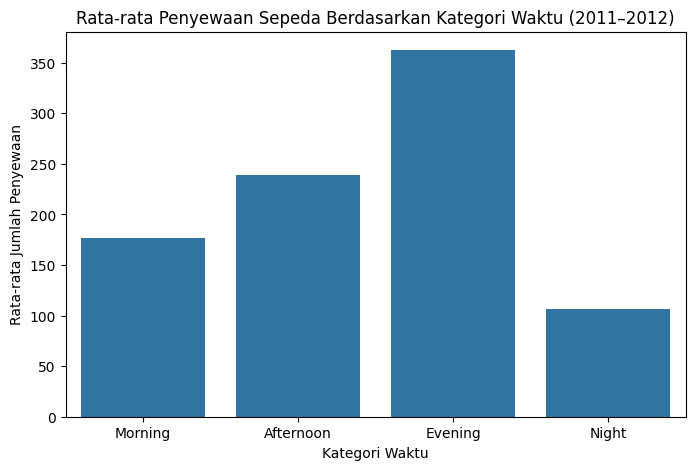

In [75]:
time_usage = df_hour.groupby('time_category')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=time_usage,
    x='time_category',
    y='cnt',
    order=['Morning','Afternoon','Evening','Night']
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Waktu (2011–2012)')
plt.xlabel('Kategori Waktu')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

**Insight:**
-
Rata-rata penyewaan sepeda menunjukkan pola yang jelas berdasarkan waktu dalam sehari. Terdapat dua puncak utama (double peak), yaitu pada kategori Morning dan Evening. Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas commuting (berangkat dan pulang kerja). Sementara itu, Afternoon memiliki tingkat penggunaan yang lebih rendah, dan Night menjadi waktu dengan rata-rata penyewaan paling rendah karena aktivitas mobilitas menurun.


### Pertanyaan 2: Pengaruh kondisi  cuaca terhadap demand

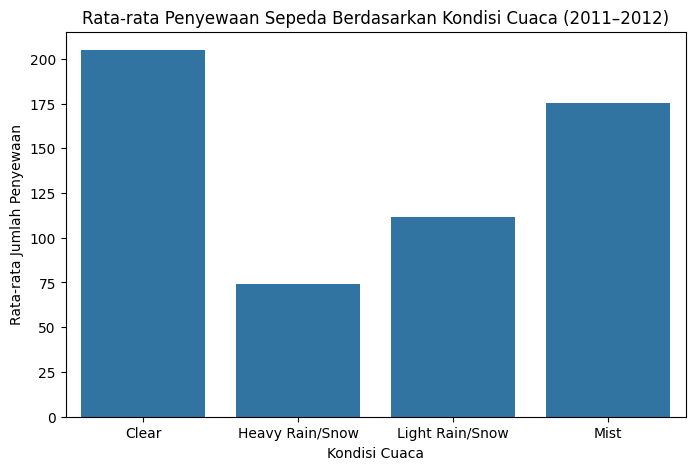

In [76]:
weather_usage = df_hour.groupby('weathersit')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=weather_usage,
    x='weathersit',
    y='cnt'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011–2012)')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

**Insight:**
-
Kondisi cuaca memiliki pengaruh signifikan terhadap rata-rata jumlah penyewaan sepeda selama periode 2011–2012. Cuaca cerah (Clear) menghasilkan rata-rata penyewaan tertinggi, diikuti oleh kondisi berkabut (Mist). Sementara itu, cuaca buruk seperti hujan ringan hingga hujan lebat menunjukkan penurunan rata-rata penyewaan yang cukup drastis. Hal ini mengindikasikan bahwa kondisi cuaca merupakan faktor eksternal utama yang memengaruhi keputusan penggunaan layanan bike sharing.

## Pertanyaan 3 : Hari Kerja vs Hari Libur


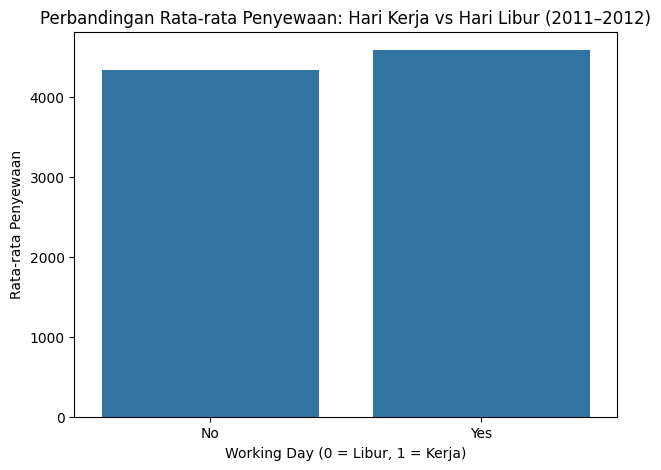

In [77]:
working_usage = df_day.groupby('workingday')['cnt'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(
    data=working_usage,
    x='workingday',
    y='cnt'
)

plt.title('Perbandingan Rata-rata Penyewaan: Hari Kerja vs Hari Libur (2011–2012)')
plt.xlabel('Working Day (0 = Libur, 1 = Kerja)')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
-
Terdapat perbedaan rata-rata penyewaan sepeda antara hari kerja dan hari libur selama periode 2011–2012. Hari kerja memiliki rata-rata penggunaan yang lebih tinggi dibandingkan hari libur. Hal ini menunjukkan bahwa sepeda lebih banyak digunakan sebagai moda transportasi untuk aktivitas rutin seperti bekerja dan sekolah, dibandingkan untuk kebutuhan rekreasi.

### Pertanyaan 4 : Distribusi Tingkat Penggunaan

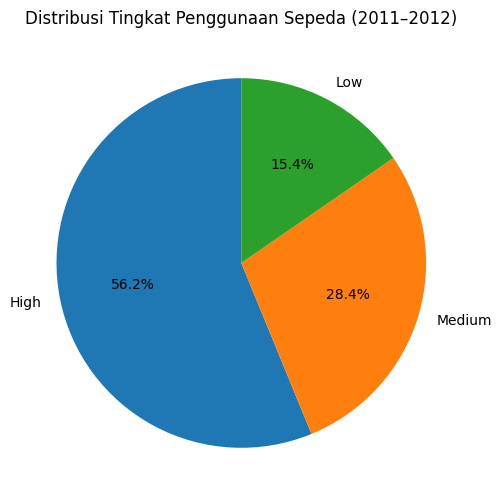

In [78]:
usage_dist = df_day['usage_level'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    usage_dist,
    labels=usage_dist.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Tingkat Penggunaan Sepeda (2011–2012)')
plt.show()

**insight:**
-
Distribusi tingkat penggunaan sepeda menunjukkan bahwa sebagian besar hari berada pada kategori Medium dan High usage. Hal ini mengindikasikan bahwa permintaan terhadap layanan bike sharing relatif stabil dan cenderung tinggi sepanjang periode pengamatan. Kondisi ini menunjukkan bahwa sistem operasional perlu dirancang untuk menangani volume permintaan yang konsisten, terutama pada hari-hari dengan tingkat penggunaan tinggi.

### Analisis Lanjutan : Clustering Berdasarkan Tingkat Penggunaan

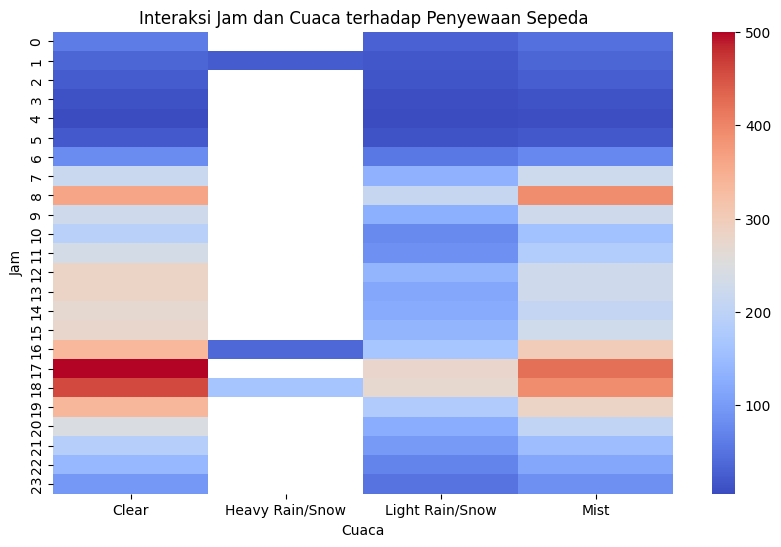

In [79]:
pivot = df_hour.pivot_table(
    values='cnt',
    index='hr',
    columns='weathersit',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')

plt.title('Interaksi Jam dan Cuaca terhadap Penyewaan Sepeda')
plt.xlabel('Cuaca')
plt.ylabel('Jam')
plt.show()

**insight:**
-
Hasil heatmap menunjukkan adanya interaksi antara jam operasional dan kondisi cuaca terhadap jumlah penyewaan sepeda. Pada kondisi cuaca cerah, pola penggunaan meningkat terutama pada jam sibuk (pagi dan sore). Sebaliknya, pada kondisi cuaca buruk seperti hujan ringan hingga berat, terjadi penurunan signifikan pada hampir semua jam. Hal ini menunjukkan bahwa meskipun pola waktu cukup konsisten, cuaca tetap menjadi faktor dominan yang mempengaruhi tingkat permintaan.

## Conclusion

### - Pertanyaan 1. Pola Penyewaan Berdasarkan Waktu

Rata-rata jumlah penyewaan sepeda menunjukkan pola yang jelas berdasarkan kategori waktu dalam sehari. Terdapat dua periode dengan tingkat penggunaan tertinggi, yaitu pagi dan sore hari. Pola ini mengindikasikan bahwa sepeda paling banyak digunakan untuk aktivitas mobilitas rutin seperti berangkat dan pulang kerja. Sementara itu, siang hari menunjukkan penurunan penggunaan, dan malam hari menjadi periode dengan rata-rata penyewaan terendah karena aktivitas masyarakat cenderung berkurang.

### -Pertanyaan 2: Pengaruh Kondisi Cuaca terhadap Penyewaan

Kondisi cuaca memiliki pengaruh yang signifikan terhadap rata-rata jumlah penyewaan sepeda selama periode 2011 hingga 2012. Cuaca cerah menghasilkan rata-rata penyewaan tertinggi, diikuti oleh kondisi berkabut. Sebaliknya, cuaca buruk seperti hujan ringan hingga hujan lebat menyebabkan penurunan yang cukup drastis pada jumlah penyewaan. Hal ini menunjukkan bahwa cuaca merupakan faktor eksternal utama yang memengaruhi keputusan pengguna dalam menggunakan layanan bike sharing.

### -Pertanyaan 3 : Perbedaan Hari Kerja dan Hari Libur

Terdapat perbedaan rata-rata penyewaan sepeda antara hari kerja dan hari libur. Hari kerja memiliki rata-rata penggunaan yang lebih tinggi dibandingkan hari libur. Hal ini menunjukkan bahwa sepeda lebih banyak digunakan sebagai alat transportasi untuk aktivitas rutin seperti bekerja dan sekolah, dibandingkan untuk aktivitas rekreasi pada hari libur.

### -Pertanyaan 4 : Distribusi Tingkat Penggunaan Sepeda

Distribusi tingkat penggunaan menunjukkan bahwa sebagian besar hari berada pada kategori penggunaan sedang hingga tinggi. Hal ini menunjukkan bahwa permintaan terhadap layanan bike sharing relatif stabil dengan tingkat penggunaan yang cukup tinggi sepanjang tahun 2011 hingga 2012. Kondisi ini mengindikasikan bahwa sistem operasional perlu dirancang agar mampu menangani permintaan yang konsisten, terutama pada periode dengan tingkat penggunaan tinggi.



In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
df_day.to_csv("df_day_clean.csv", index=False)
df_hour.to_csv("df_hour_clean.csv", index=False)

In [82]:
from google.colab import files
files.download("df_day_clean.csv")
files.download("df_hour_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>